# `build_features.py`

Giai đoạn 6a (de) — sinh ma trận feature thuần lịch cho model Phần B: mở rộng bảng Tết 2012-2025, hàm `build_calendar_features` dùng chung train/forecast, xuất `features_train.csv`/`features_forecast.csv` + QC (không trùng/thiếu ngày, NaN, `days_from_tet` liên tục, so phân bố month/dow). Có 1 chart QC (`qc_month_dow_distribution.png`). Notebook chạy đúng code gốc (các hàm giữ nguyên, phần `if __name__ == "__main__":` được unwrap thành cell notebook chạy tuần tự), chart hiện inline.

In [1]:
%matplotlib inline
import os
os.chdir(r"/Users/lhoanghai_/Downloads/Dự án datathon2026")
__file__ = r"/Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase6_features/build_features.py"  # notebook không có __file__ mặc định -> gán thủ công để mọi Path(__file__)... trong code gốc resolve đúng thư mục như khi chạy .py


## Thiết lập / import

In [2]:
# Giai đoạn 6a (de) — Sinh ma trận feature THUẦN LỊCH cho model Phần B
# (Revenue + COGS, 548 ngày 2023-01-01 -> 2024-07-01)
#
# CHỈ đọc: data/sales.csv, data/sample_submission.csv,
#          EDA_Insight/phase1_descriptive/data/tet_dates.csv (đối chiếu, KHÔNG ghi đè)
# CHỈ ghi: EDA_Insight/phase6_features/data/{tet_dates_extended,features_train,features_forecast}.csv
#          EDA_Insight/output/phase6/qc_*.png
#
# Định nghĩa feature GHIM theo brief Giai đoạn 6a — không tự đổi công thức.
# Chạy lại: .venv/bin/python EDA_Insight/phase6_features/build_features.py

import sys
import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use("Agg")  # bỏ trong notebook để %matplotlib inline hiển thị chart
import matplotlib.pyplot as plt
from lunardate import LunarDate
from pathlib import Path

HERE = Path(__file__).resolve().parent                 # EDA_Insight/phase6_features/
ROOT = HERE.parent.parent                               # <project root>
DATA = ROOT / "data"                                     # data gốc, CHỈ ĐỌC
EXPORT = HERE / "data"
EXPORT.mkdir(parents=True, exist_ok=True)
OUT = HERE.parent / "output" / "phase6"
OUT.mkdir(parents=True, exist_ok=True)
TET_REF = HERE.parent / "phase1_descriptive" / "data" / "tet_dates.csv"   # chỉ đọc, đối chiếu

TREND_ANCHOR = pd.Timestamp("2012-07-04")   # neo cố định trend_index=0

## 1. Mở rộng bảng Tết 2012-2025 + đối chiếu 2013-2022 với tet_dates.csv (Phase 1)

In [3]:
def build_tet_dates_extended():
    rows = []
    for year in range(2012, 2026):
        solar = LunarDate(year, 1, 1).to_solar_date()
        rows.append({"year": year, "tet_date": pd.Timestamp(solar)})
    tet = pd.DataFrame(rows)

    ref = pd.read_csv(TET_REF, parse_dates=["tet_date"])
    merged = tet.merge(ref, on="year", suffixes=("_new", "_ref"))
    mismatch = merged[merged["tet_date_new"] != merged["tet_date_ref"]]
    if len(mismatch) > 0:
        print("DỪNG — lệch với tet_dates.csv Phase 1, KHÔNG ghi đè:")
        print(mismatch)
        sys.exit(1)
    print(f"Đối chiếu Tết 2013-2022 với Phase 1: KHỚP 100% ({len(merged)} năm).")

    tet.to_csv(EXPORT / "tet_dates_extended.csv", index=False)
    print(f"Đã lưu {EXPORT / 'tet_dates_extended.csv'} ({len(tet)} năm, 2012-2025).")
    return tet

## 2. days_from_tet — vector hoá bằng searchsorted, chọn Tết gần nhất theo |khoảng cách|

In [4]:
def compute_days_from_tet(dates: pd.Series, tet_dates: pd.Series) -> np.ndarray:
    tet_sorted = np.sort(tet_dates.values.astype("datetime64[D]"))
    d = dates.values.astype("datetime64[D]")

    idx_right = np.searchsorted(tet_sorted, d, side="left")
    idx_right_c = np.clip(idx_right, 0, len(tet_sorted) - 1)
    idx_left_c = np.clip(idx_right - 1, 0, len(tet_sorted) - 1)

    delta_right = (d - tet_sorted[idx_right_c]).astype("timedelta64[D]").astype(int)
    delta_left = (d - tet_sorted[idx_left_c]).astype("timedelta64[D]").astype(int)

    pick_left = np.abs(delta_left) <= np.abs(delta_right)
    return np.where(pick_left, delta_left, delta_right)

## 3. Hàm build feature lịch CHUNG cho cả train và forecast (không leakage)

In [5]:
def build_calendar_features(dates: pd.DatetimeIndex, tet_dates: pd.Series) -> pd.DataFrame:
    d = pd.Series(pd.to_datetime(dates))
    f = pd.DataFrame(index=d.values)
    f.index.name = "Date"

    f["year"] = d.dt.year.values
    f["month"] = d.dt.month.values
    f["quarter"] = d.dt.quarter.values
    f["day_of_week"] = d.dt.dayofweek.values          # 0=Thu Hai ... 6=Chu Nhat
    f["day_of_month"] = d.dt.day.values

    f["month_sin"] = np.sin(2 * np.pi * f["month"] / 12)
    f["month_cos"] = np.cos(2 * np.pi * f["month"] / 12)
    f["dow_sin"] = np.sin(2 * np.pi * f["day_of_week"] / 7)
    f["dow_cos"] = np.cos(2 * np.pi * f["day_of_week"] / 7)

    f["is_post_2019"] = (d.values >= np.datetime64("2019-01-01")).astype(int)
    f["is_post_2019_transition"] = (
        (d.values >= np.datetime64("2019-01-01")) & (d.values <= np.datetime64("2021-12-31"))
    ).astype(int)

    f["days_from_tet"] = compute_days_from_tet(d, tet_dates)

    f["is_low_margin_season"] = f["month"].isin([7, 8, 9, 11, 12]).astype(int)

    f["trend_index"] = (d - TREND_ANCHOR).dt.days.values

    month_day = d.dt.strftime("%m-%d")
    f["is_holiday_302_305"] = month_day.isin(["04-30", "05-01"]).astype(int).values
    f["is_holiday_qk"] = (month_day == "09-02").astype(int).values
    f["is_christmas"] = (month_day == "12-25").astype(int).values

    return f

## 4. Build features_train.csv

In [6]:
def build_train(tet_dates: pd.Series) -> pd.DataFrame:
    sales = pd.read_csv(DATA / "sales.csv", parse_dates=["Date"])
    assert not sales["Date"].duplicated().any(), "sales.csv có ngày trùng"
    assert sales["Date"].is_monotonic_increasing, "sales.csv không theo thứ tự ngày tăng dần"

    feats = build_calendar_features(sales["Date"], tet_dates)
    feats = feats.reset_index().rename(columns={"index": "Date"})
    feats["is_partial_year_2012"] = (feats["Date"].dt.year == 2012).astype(int)

    train = feats.merge(sales[["Date", "Revenue", "COGS"]], on="Date", how="left")
    assert train["Revenue"].notna().all() and train["COGS"].notna().all(), \
        "target NaN sau khi join — join lệch ngày"
    assert len(train) == len(sales), "số dòng train khác số dòng sales.csv gốc"

    train.to_csv(EXPORT / "features_train.csv", index=False)
    print(f"Đã lưu {EXPORT / 'features_train.csv'} ({len(train)} dòng).")
    return train

## 5. Build features_forecast.csv

In [7]:
def build_forecast(tet_dates: pd.Series) -> pd.DataFrame:
    sub = pd.read_csv(DATA / "sample_submission.csv", parse_dates=["Date"])
    assert not sub["Date"].duplicated().any(), "sample_submission.csv có ngày trùng"
    assert sub["Date"].is_monotonic_increasing, "sample_submission.csv không theo thứ tự ngày tăng dần"
    assert len(sub) == 548, f"sample_submission.csv không phải 548 dòng, đang là {len(sub)}"

    feats = build_calendar_features(sub["Date"], tet_dates)
    feats = feats.reset_index().rename(columns={"index": "Date"})

    assert len(feats) == 548, f"features_forecast phải 548 dòng, đang {len(feats)}"
    assert set(feats["Date"]) == set(sub["Date"]), "tập ngày forecast KHÔNG khớp sample_submission.csv"

    feats.to_csv(EXPORT / "features_forecast.csv", index=False)
    print(f"Đã lưu {EXPORT / 'features_forecast.csv'} ({len(feats)} dòng).")
    return feats

## 6. QC

In [8]:
def qc(train: pd.DataFrame, forecast: pd.DataFrame):
    print("\n=== QC bước 5 ===")

    # 6.1 không trùng / thiếu ngày
    train_days = pd.date_range(train["Date"].min(), train["Date"].max(), freq="D")
    missing_train = set(train_days) - set(train["Date"])
    dup_train = train["Date"].duplicated().sum()
    print(f"[train] thiếu ngày: {len(missing_train)}, trùng ngày: {dup_train}")
    assert len(missing_train) == 0 and dup_train == 0

    dup_fc = forecast["Date"].duplicated().sum()
    print(f"[forecast] trùng ngày: {dup_fc}, số dòng: {len(forecast)} (kỳ vọng 548)")
    assert dup_fc == 0 and len(forecast) == 548

    # 6.2 NaN ngoài ý muốn
    nan_train = train.isna().sum()
    nan_train = nan_train[nan_train > 0]
    nan_fc = forecast.isna().sum()
    nan_fc = nan_fc[nan_fc > 0]
    if len(nan_train) == 0:
        print("[train] không có NaN.")
    else:
        print("[train] CÓ NaN ở các cột:\n", nan_train)
    if len(nan_fc) == 0:
        print("[forecast] không có NaN.")
    else:
        print("[forecast] CÓ NaN ở các cột:\n", nan_fc)

    # 6.3 days_from_tet liên tục qua ranh giới năm — kiểm quanh Tết 2019, 2023, 2024
    print("\n[days_from_tet] quanh ranh giới năm/Tết (train quanh Tết 2019, forecast quanh Tết 2023-2024):")
    for label, df, center in [
        ("Tet 2019 (train)", train, pd.Timestamp("2019-02-05")),
        ("Tet 2023 (forecast)", forecast, pd.Timestamp("2023-01-22")),
        ("Tet 2024 (forecast)", forecast, pd.Timestamp("2024-02-10")),
    ]:
        lo, hi = center - pd.Timedelta(days=4), center + pd.Timedelta(days=4)
        window = df[(df["Date"] >= lo) & (df["Date"] <= hi)][["Date", "days_from_tet"]]
        print(f"-- {label} --")
        print(window.to_string(index=False))
        diffs = window["days_from_tet"].diff().dropna()
        assert (diffs == 1).all(), f"days_from_tet không liên tục (+1/ngày) quanh {label}"

    # kiểm thêm ranh giới năm dương lịch (31/12 -> 1/1), tránh lỗi lệch năm khi tính days_from_tet
    print("\n[days_from_tet] quanh ranh giới năm dương lịch 31/12 -> 1/1:")
    for label, df, center in [
        ("2018/2019", train, pd.Timestamp("2019-01-01")),
        ("2022/2023 (train->forecast)", None, pd.Timestamp("2023-01-01")),
    ]:
        if label == "2022/2023 (train->forecast)":
            w1 = train[train["Date"] >= pd.Timestamp("2022-12-29")][["Date", "days_from_tet"]]
            w2 = forecast[forecast["Date"] <= pd.Timestamp("2023-01-04")][["Date", "days_from_tet"]]
            window = pd.concat([w1, w2])
        else:
            lo, hi = center - pd.Timedelta(days=4), center + pd.Timedelta(days=4)
            window = df[(df["Date"] >= lo) & (df["Date"] <= hi)][["Date", "days_from_tet"]]
        print(f"-- {label} --")
        print(window.to_string(index=False))
        diffs = window["days_from_tet"].diff().dropna()
        assert (diffs == 1).all(), f"days_from_tet không liên tục (+1/ngày) qua ranh giới {label}"

    # 6.4 bảng so phân bố month / day_of_week train vs forecast
    print("\n[phân bố month] train vs forecast (tỷ lệ %):")
    m_train = (train["month"].value_counts(normalize=True) * 100).sort_index().round(2)
    m_fc = (forecast["month"].value_counts(normalize=True) * 100).sort_index().round(2)
    m_cmp = pd.DataFrame({"train_%": m_train, "forecast_%": m_fc})
    print(m_cmp.to_string())

    print("\n[phân bố day_of_week] train vs forecast (tỷ lệ %):")
    w_train = (train["day_of_week"].value_counts(normalize=True) * 100).sort_index().round(2)
    w_fc = (forecast["day_of_week"].value_counts(normalize=True) * 100).sort_index().round(2)
    w_cmp = pd.DataFrame({"train_%": w_train, "forecast_%": w_fc})
    print(w_cmp.to_string())

    # QC chart
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].bar(m_cmp.index - 0.15, m_cmp["train_%"], width=0.3, label="train (2012-2022)")
    axes[0].bar(m_cmp.index + 0.15, m_cmp["forecast_%"], width=0.3, label="forecast (2023-2024)")
    axes[0].set_title("Phân bố % theo month")
    axes[0].set_xlabel("month")
    axes[0].legend()

    axes[1].bar(w_cmp.index - 0.15, w_cmp["train_%"], width=0.3, label="train")
    axes[1].bar(w_cmp.index + 0.15, w_cmp["forecast_%"], width=0.3, label="forecast")
    axes[1].set_title("Phân bố % theo day_of_week (0=T2..6=CN)")
    axes[1].set_xlabel("day_of_week")
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(OUT / "qc_month_dow_distribution.png", dpi=120)
    plt.show()
    plt.close(fig)
    print(f"\nĐã lưu chart QC: {OUT / 'qc_month_dow_distribution.png'}")

    print("\nQC PASS — không trùng/thiếu ngày, days_from_tet liên tục, đã in bảng so phân bố.")

## Chạy pipeline (tương đương `if __name__ == "__main__":` ở bản .py — Jupyter luôn có `__name__ == "__main__"` nên khối này vốn tự chạy được cả khi giữ nguyên `if`; tách/dedent ở đây chỉ để hiện thành cell riêng, không đổi logic)

Đối chiếu Tết 2013-2022 với Phase 1: KHỚP 100% (13 năm).
Đã lưu /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase6_features/data/tet_dates_extended.csv (14 năm, 2012-2025).
Đã lưu /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase6_features/data/features_train.csv (3833 dòng).
Đã lưu /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase6_features/data/features_forecast.csv (548 dòng).

=== QC bước 5 ===
[train] thiếu ngày: 0, trùng ngày: 0
[forecast] trùng ngày: 0, số dòng: 548 (kỳ vọng 548)
[train] không có NaN.
[forecast] không có NaN.

[days_from_tet] quanh ranh giới năm/Tết (train quanh Tết 2019, forecast quanh Tết 2023-2024):
-- Tet 2019 (train) --
      Date  days_from_tet
2019-02-01             -4
2019-02-02             -3
2019-02-03             -2
2019-02-04             -1
2019-02-05              0
2019-02-06              1
2019-02-07              2
2019-02-08              3
2019-02-09              4
-- Tet 2023 (forecast) --
      Date  

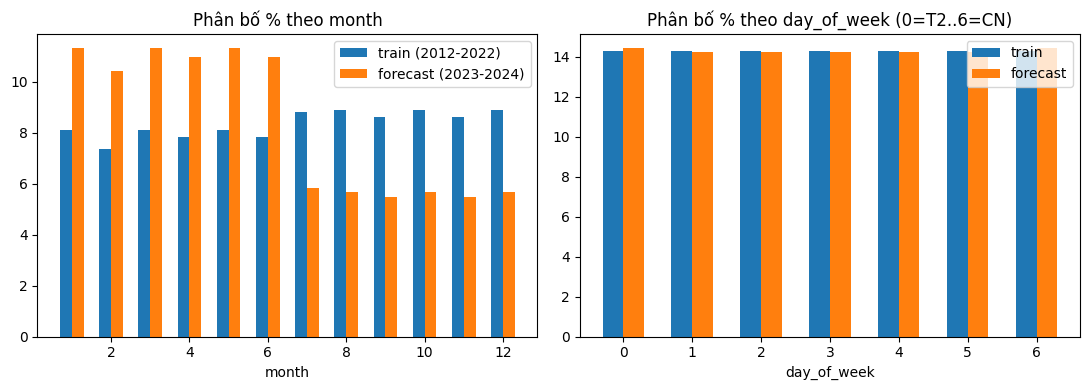


Đã lưu chart QC: /Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/output/phase6/qc_month_dow_distribution.png

QC PASS — không trùng/thiếu ngày, days_from_tet liên tục, đã in bảng so phân bố.

=== XONG Giai đoạn 6a (de) ===
features_train.csv: 3833 dòng (kỳ vọng 3833, khớp sales.csv)
features_forecast.csv: 548 dòng (kỳ vọng 548, khớp sample_submission.csv)


In [9]:
tet_ext = build_tet_dates_extended()
tet_series = tet_ext["tet_date"]

train = build_train(tet_series)
forecast = build_forecast(tet_series)
qc(train, forecast)

print("\n=== XONG Giai đoạn 6a (de) ===")
print(f"features_train.csv: {len(train)} dòng (kỳ vọng 3833, khớp sales.csv)")
print(f"features_forecast.csv: {len(forecast)} dòng (kỳ vọng 548, khớp sample_submission.csv)")